In [45]:
import numpy as np
import pandas as pd

"""
    Input:
        games_path (str)
            Path to league games CSV (e.g., nba_data.csv)
        standings_path (str)
            Path to end-of-season ranks CSV  (e.g., end_of_season_nba.csv)
        out_path (str or None, default=None)
            If provided, write the updated games to this CSV.
    Returns:
        DataFrame: original games + home_rank, away_rank, is_upset (1 or 0)
    How it works:
        We add the rank of each team to the game, so we know home_rank and away_rank
        Uses `result` + ranks to set is_upset (1 = upset, 0 = not an upset)
        So if a lower ranked team wins then it is an upset
        The code then write this new csv as 'league'_data_with_upset.csv
"""
def add_upset_column(games_path, standings_path, out_path=None):
    g = pd.read_csv(games_path)
    s = (pd.read_csv(standings_path)[["season", "team_id", "rank"]]
         .dropna(subset=["rank"]))

    # add ranks for both teams
    g = g.merge(s.rename(columns={"team_id": "team1", "rank": "home_rank"}),
                how="left", on=["season", "team1"])
    g = g.merge(s.rename(columns={"team_id": "team2", "rank": "away_rank"}),
                how="left", on=["season", "team2"])

    # start with 0 (not an upset) for everyone
    g["is_upset"] = pd.Series(0, index=g.index, dtype="Int64")

    is_tie = g["result"] == 1
    non_tie = g["result"].isin([0, 3])
    ranks_present = g["home_rank"].notna() & g["away_rank"].notna()

    # only compute upset on non-ties with ranks
    stronger_home = g["home_rank"] < g["away_rank"]
    upset_homewin = (g["result"] == 3) & (~stronger_home)
    upset_awaywin = (g["result"] == 0) & (stronger_home)
    upset_mask = non_tie & ranks_present & (upset_homewin | upset_awaywin)

    g.loc[upset_mask, "is_upset"] = 1

    # non-tie games with missing rank(s) are <NA>
    g.loc[non_tie & (~ranks_present), "is_upset"] = pd.NA

    # ties remain as 0 meaning not an upset
    if out_path is not None:
        g.to_csv(out_path, index=False)
        print(f"Wrote games with is_upset to {out_path} (rows: {len(g):,})")

    return g


In [46]:
#leagues to process
leagues = ["nfl", "nba", "mlb"]

# dict of dataframes with LEAGUE CODE (e.g., "NFL") being the key
with_upset = {}  

for lg in leagues:
    games_path = f"../csv/{lg}_data.csv"
    standings_path = f"../csv/end_of_season_{lg}.csv"
    out_path = f"../csv/{lg}_data_with_upset.csv"
    df = add_upset_column(games_path, standings_path, out_path=out_path)
    df["league"] = lg.upper()
    with_upset[lg.upper()] = df

# combined frame of all leagues
all_games = pd.concat(with_upset.values(), ignore_index=True)
valid_games = all_games[all_games["is_upset"].notna()].copy()


Wrote games with is_upset to ../csv/nfl_data_with_upset.csv (rows: 13,500)
Wrote games with is_upset to ../csv/nba_data_with_upset.csv (rows: 66,410)
Wrote games with is_upset to ../csv/mlb_data_with_upset.csv (rows: 101,135)


In [47]:
# Season level upset frequency by league (for line & box plots)
season_by_league = (valid_games
                    .groupby(["league", "season"])["is_upset"]
                    .mean()
                    .reset_index()
                    .rename(columns={"is_upset": "upset_freq"}))

# ALL teams in a league, upset
# Creates two rows per game (one from home persepective(team1) and one from away persepective(team2)).
# Then group by team and the mean of is_upset will give the percentage.
# Returns a dataframe sorted from highest to lowest upset rate.
def team_upset_rates(df_one_league):
    teams_long = pd.concat([
        df_one_league[["team1", "is_upset"]].rename(columns={"team1": "team"}),
        df_one_league[["team2", "is_upset"]].rename(columns={"team2": "team"}),
    ], ignore_index=True)
    return (teams_long.groupby("team")["is_upset"].mean()
            .reset_index()
            .rename(columns={"is_upset": "upset_rate"})
            .sort_values("upset_rate", ascending=False))

nfl_rates = team_upset_rates(with_upset["NFL"][with_upset["NFL"]["is_upset"].notna()])
nba_rates = team_upset_rates(with_upset["NBA"][with_upset["NBA"]["is_upset"].notna()])
mlb_rates = team_upset_rates(with_upset["MLB"][with_upset["MLB"]["is_upset"].notna()])


In [48]:

"""
    Input:
        league_name (str) (e.g., "NFL", "NBA", "MLB")
        league_df (pd.DataFrame)
            DataFrame of leagues with is_upset column
    Returns:
        None
            code display a bar chart of each teams upset rate
    How it works:
        Takes each game and covertes into two rows one from hoem eprsepctive and one for away perspective.
        Groups by team and gets the upset percenatge by taking mean of is_upset.
        Then the results are plotted.
"""
def plot_team_upset_bars(league_name, league_df):
    # league_df should be the games-with-upset for ONE league
    teams_long = pd.concat([
        league_df[["team1", "is_upset"]].rename(columns={"team1":"team"}),
        league_df[["team2", "is_upset"]].rename(columns={"team2":"team"}),
    ], ignore_index=True).dropna(subset=["is_upset"])

    rates = (teams_long.groupby("team")["is_upset"].mean()
             .reset_index().rename(columns={"is_upset":"upset_rate"})
             .sort_values("upset_rate", ascending=False))

    n = len(rates)
    fig_w = max(12, n * 0.35)

    plt.figure(figsize=(fig_w, 6))
    plt.bar(rates["team"].astype(str), rates["upset_rate"])
    plt.xticks(rotation=45, ha="right")
    ax = plt.gca()
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    plt.ylabel("Upset Frequency (%)")
    plt.title(f"{league_name} Team Upset Frequencies")
    plt.ylim(bottom=0.0)
    plt.tight_layout()
    plt.show()


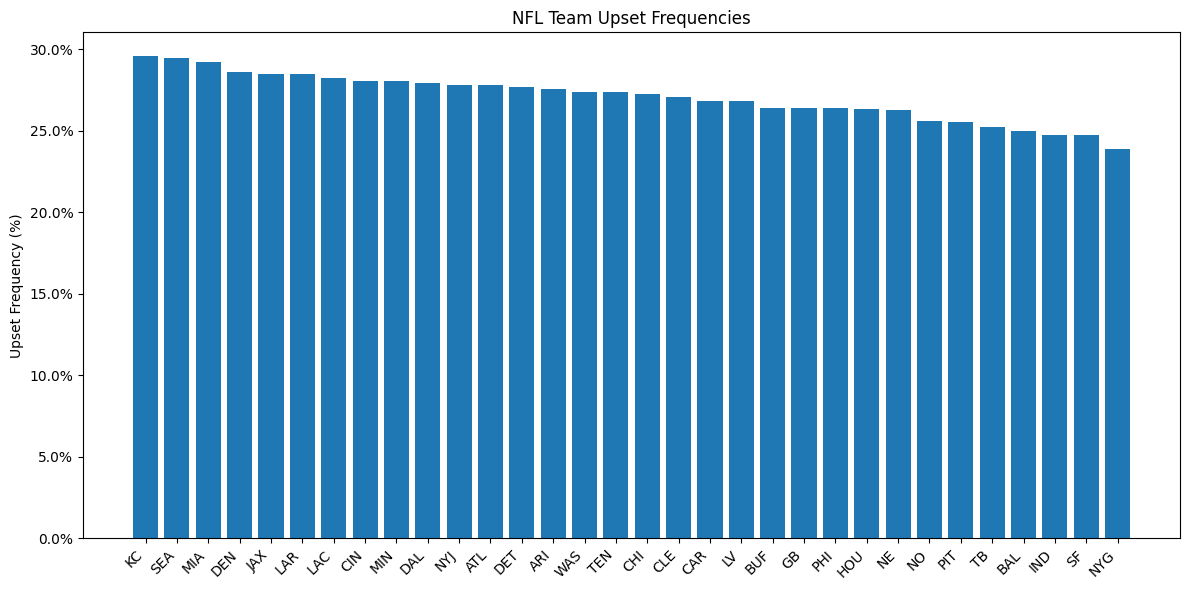

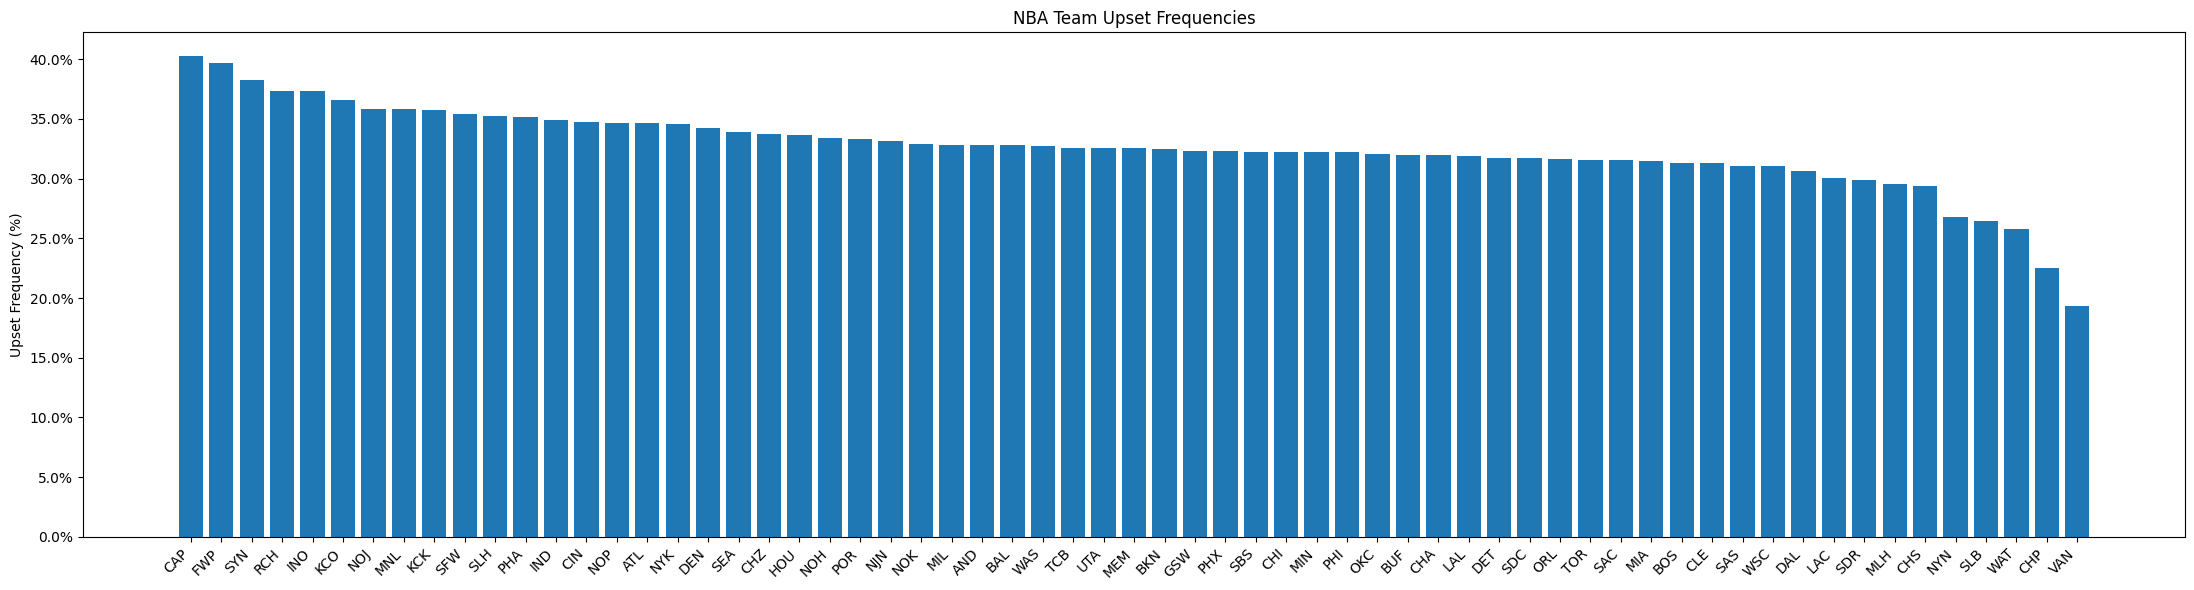

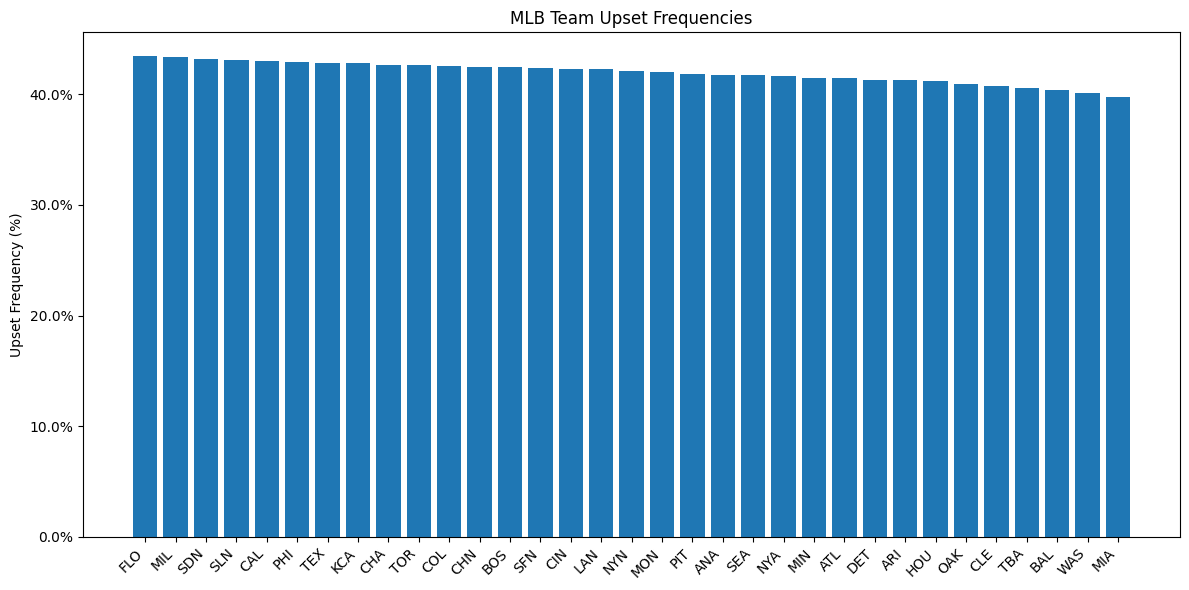

In [49]:
for lg, df in with_upset.items():
    plot_team_upset_bars(lg, df)

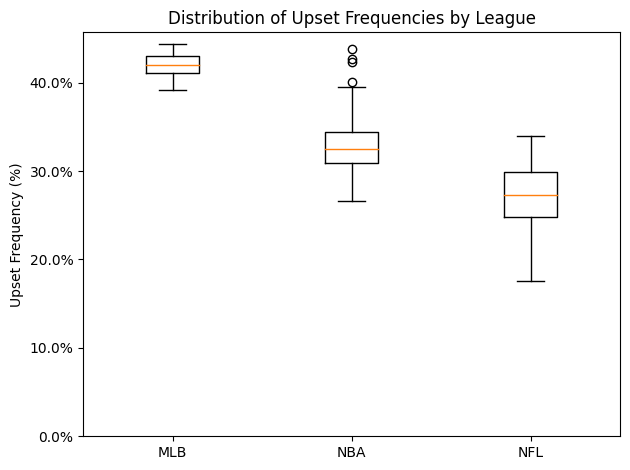

In [50]:
# Box distribution of seasonal upset frequencies by league
box_source = season_by_league.copy()

plt.figure()
data = [grp["upset_freq"].values for _, grp in box_source.groupby("league")]
labels = [lg for lg, _ in box_source.groupby("league")]
plt.boxplot(data, labels=labels)
plt.ylabel("Upset Frequency (%)")
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
plt.title("Distribution of Upset Frequencies by League")
plt.ylim(bottom=0.0)
plt.tight_layout()


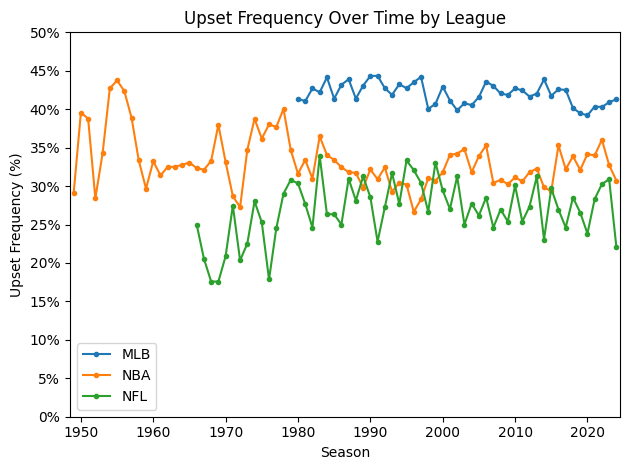

In [58]:
# Upset Frequency over time by league
line = season_by_league.sort_values(["league", "season"])
fig, ax = plt.subplots()

for lg, g in line.groupby("league"):
    ax.plot(g["season"].astype(int), g["upset_freq"],
            marker="o", markersize=3, linewidth=1.5, label=lg)

ax.set_xlabel("Season")
ax.set_ylabel("Upset Frequency (%)")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_title("Upset Frequency Over Time by League")
ax.set_ylim(0.0, 0.5)
ax.set_yticks([i/100 for i in range(0, 51, 5)])

xmin, xmax = int(line["season"].min()), int(line["season"].max())
decades = list(range((xmin//10)*10, (xmax//10)*10 + 1, 10))
ax.set_xticks(decades)
ax.set_xticklabels([str(d) for d in decades])
ax.set_xlim(xmin - 0.5, xmax + 0.5)

ax.legend()
fig.tight_layout()
